In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV
df = pd.read_csv('layoffs.csv')

# Check what we're working with
print(df.shape)
print(df.columns.tolist())
print(df.head())

(4361, 11)
['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off', 'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added']
      company          location  total_laid_off       date  \
0        Acko  Mumbai, Non-U.S.            60.0  4/20/2026   
1        Meta       SF Bay Area          8000.0  4/17/2026   
2  Shutterfly   Haifa, Non-U.S.            80.0  4/16/2026   
3       Quora       SF Bay Area             NaN  4/16/2026   
4        Snap       Los Angeles          1000.0  4/15/2026   

   percentage_laid_off       industry  \
0                 0.05        Finance   
1                 0.10       Consumer   
2                  NaN  Manufacturing   
3                  NaN       Consumer   
4                 0.16       Consumer   

                                              source     stage  funds_raised  \
0  https://inc42.com/buzz/acko-cuts-5-workforce-i...   Unknown         143.0   
1  https://www.reuters.com/world/meta-targets-may...  Post-IPO  

In [33]:
# Drop source column - not needed for analysis
df = df.drop(columns=['source'])

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Load into SQLite
conn = sqlite3.connect('layoffs.db')
df.to_sql('layoffs', conn, if_exists='replace', index=False)

print("Rows loaded:", pd.read_sql("SELECT COUNT(*) as total FROM layoffs", conn).iloc[0,0])

Rows loaded: 4361


In [35]:
# Check nulls in key columns
pd.read_sql("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN total_laid_off IS NULL THEN 1 ELSE 0 END) as null_laid_off,
        SUM(CASE WHEN industry IS NULL THEN 1 ELSE 0 END) as null_industry,
        SUM(CASE WHEN country IS NULL THEN 1 ELSE 0 END) as null_country,
        SUM(CASE WHEN stage IS NULL THEN 1 ELSE 0 END) as null_stage
    FROM layoffs
""", conn)

,total_rows,null_laid_off,null_industry,null_country,null_stage
0,4361,1510,2,2,5


In [37]:
# Query 1 - Industry Impact Analysis
# Aggregates total layoffs, number of companies, and average per company by industry
# to identify which sectors were hit hardest in absolute and relative terms.

In [39]:
pd.read_sql("""
    SELECT 
        industry,
        SUM(total_laid_off) as total_laid_off,
        COUNT(DISTINCT company) as num_companies,
        ROUND(AVG(total_laid_off), 0) as avg_per_company
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    AND industry IS NOT NULL
    GROUP BY industry
    ORDER BY total_laid_off DESC
""", conn)

,industry,total_laid_off,num_companies,avg_per_company
0,Other,119284.0,121,645.0
1,Retail,106076.0,157,453.0
2,Hardware,105957.0,31,1962.0
3,Consumer,96215.0,117,496.0
4,Transportation,66002.0,112,361.0
5,Finance,58694.0,251,171.0
6,Food,51998.0,102,327.0
7,Healthcare,38904.0,164,189.0
8,Travel,23720.0,48,321.0
9,Sales,21269.0,35,367.0


In [41]:
# Query 2 - Yearly Layoff Trends
# Breaks down total layoffs and affected companies by year to show
# how the layoff wave evolved from COVID-19 through 2026.

In [43]:
pd.read_sql("""
    SELECT 
        strftime('%Y', date) as year,
        SUM(total_laid_off) as total_laid_off,
        COUNT(DISTINCT company) as num_companies
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    GROUP BY year
    ORDER BY year
""", conn)

,year,total_laid_off,num_companies
0,None,700.0,1
1,2020,80998.0,450
2,2021,15823.0,30
3,2022,165269.0,718
4,2023,264320.0,749
5,2024,152922.0,346
6,2025,124201.0,187
7,2026,92272.0,62


In [45]:
# Query 3 - Top 10 Companies by Total Layoffs
# Identifies the largest individual contributors to total layoffs,
# including number of rounds to show repeated cutting patterns.

In [47]:
pd.read_sql("""
    SELECT 
        company,
        industry,
        country,
        SUM(total_laid_off) as total_laid_off,
        COUNT(*) as num_rounds
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    GROUP BY company, industry, country
    ORDER BY total_laid_off DESC
    LIMIT 10
""", conn)

,company,industry,country,total_laid_off,num_rounds
0,Amazon,Retail,United States,58124.0,13
1,Intel,Hardware,United States,43115.0,9
2,Meta,Consumer,United States,35700.0,9
3,Oracle,Other,United States,31294.0,8
4,Microsoft,Other,United States,30055.0,10
5,Dell,Hardware,United States,23650.0,3
6,Salesforce,Sales,United States,16475.0,11
7,Cisco,Infrastructure,United States,14521.0,5
8,Tesla,Transportation,United States,14500.0,2
9,Google,Consumer,United States,13697.0,10


In [49]:
# Query 4 - Layoffs by Company Stage
# Analyzes whether a company's funding stage predicts layoff volume,
# comparing Post-IPO giants against early stage startups.

In [51]:
pd.read_sql("""
    SELECT 
        stage,
        SUM(total_laid_off) as total_laid_off,
        COUNT(DISTINCT company) as num_companies,
        ROUND(AVG(total_laid_off), 0) as avg_per_company
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    AND stage IS NOT NULL
    GROUP BY stage
    ORDER BY total_laid_off DESC
""", conn)

,stage,total_laid_off,num_companies,avg_per_company
0,Post-IPO,564932.0,373,773.0
1,Unknown,79598.0,353,180.0
2,Acquired,71753.0,212,277.0
3,Series B,30822.0,263,101.0
4,Series C,27412.0,227,97.0
5,Series D,27054.0,181,109.0
6,Series E,24798.0,108,162.0
7,Series F,16671.0,61,183.0
8,Private Equity,12826.0,40,273.0
9,Series A,9147.0,142,58.0


In [53]:
# Query 5 - Rolling Monthly Totals
# Uses a CTE and window function to calculate cumulative layoffs over time,
# revealing the acceleration and peak of the layoff wave.

In [55]:
pd.read_sql("""
    WITH monthly AS (
        SELECT 
            strftime('%Y-%m', date) as month,
            SUM(total_laid_off) as monthly_total
        FROM layoffs
        WHERE total_laid_off IS NOT NULL
        AND date IS NOT NULL
        GROUP BY month
    )
    SELECT 
        month,
        monthly_total,
        SUM(monthly_total) OVER (ORDER BY month) as rolling_total
    FROM monthly
    ORDER BY month
""", conn)

,month,monthly_total,rolling_total
0,2020-03,9628.0,9628.0
1,2020-04,26710.0,36338.0
2,2020-05,25804.0,62142.0
3,2020-06,7627.0,69769.0
4,2020-07,7112.0,76881.0
...,...,...,...
68,2025-12,1552.0,803533.0
69,2026-01,24928.0,828461.0
70,2026-02,11019.0,839480.0
71,2026-03,45800.0,885280.0


In [57]:
# Query 6 - Top 5 Companies Per Year
# Uses nested CTEs and DENSE_RANK() window function to identify the
# biggest cutters each year, showing how leadership changed over time.

In [59]:
pd.read_sql("""
    WITH company_year AS (
        SELECT 
            company,
            strftime('%Y', date) as year,
            SUM(total_laid_off) as total_laid_off
        FROM layoffs
        WHERE total_laid_off IS NOT NULL
        AND date IS NOT NULL
        GROUP BY company, year
    ),
    ranked AS (
        SELECT *,
            DENSE_RANK() OVER (PARTITION BY year ORDER BY total_laid_off DESC) as rank
        FROM company_year
    )
    SELECT * FROM ranked
    WHERE rank <= 5
    ORDER BY year, rank
""", conn)

,company,year,total_laid_off,rank
0,Uber,2020,7525.0,1
1,Booking.com,2020,4375.0,2
2,Groupon,2020,2800.0,3
3,Swiggy,2020,2250.0,4
4,Airbnb,2020,1900.0,5
5,Bytedance,2021,3600.0,1
6,Katerra,2021,2434.0,2
7,Zillow,2021,2000.0,3
8,Instacart,2021,1877.0,4
9,WhiteHat Jr,2021,1800.0,5


In [61]:
# Query 7 - Geographic Distribution
# Identifies which countries experienced the most layoffs to show
# whether this is primarily a US phenomenon or a global trend.

In [63]:
pd.read_sql("""
    SELECT 
        country,
        SUM(total_laid_off) as total_laid_off,
        COUNT(DISTINCT company) as num_companies
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    AND country IS NOT NULL
    GROUP BY country
    ORDER BY total_laid_off DESC
    LIMIT 10
""", conn)

,country,total_laid_off,num_companies
0,United States,637509.0,1181
1,India,65644.0,179
2,Germany,31588.0,72
3,United Kingdom,23264.0,70
4,Netherlands,21575.0,13
5,Sweden,20159.0,18
6,Canada,16002.0,97
7,Israel,13107.0,92
8,Brazil,11939.0,58
9,China,8190.0,11


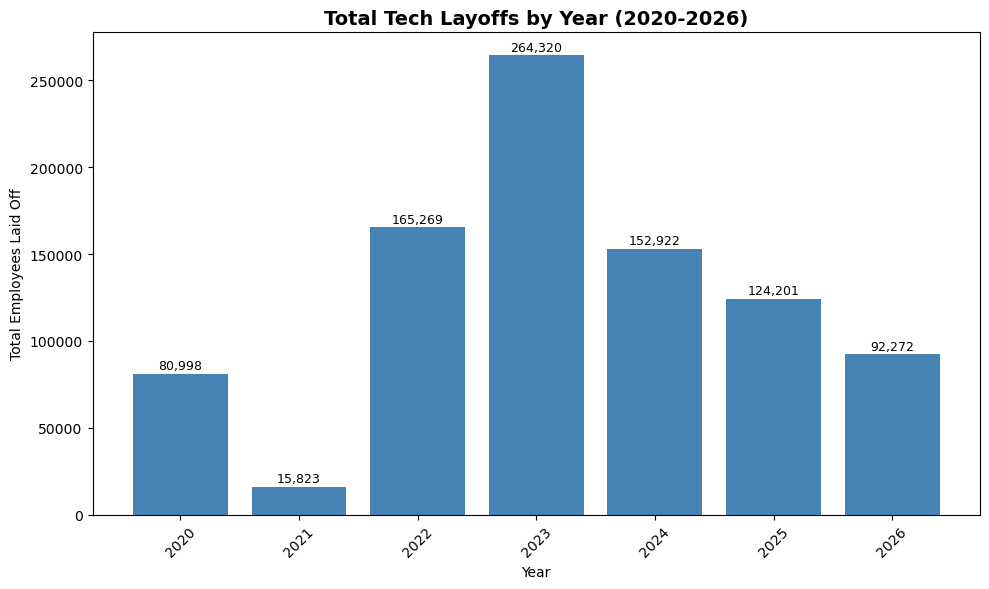

In [65]:
# Chart 1 - Total layoffs by year
year_data = pd.read_sql("""
    SELECT 
        strftime('%Y', date) as year,
        SUM(total_laid_off) as total_laid_off
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    AND date IS NOT NULL
    AND strftime('%Y', date) != 'None'
    GROUP BY year
    ORDER BY year
""", conn)

plt.figure(figsize=(10, 6))
bars = plt.bar(year_data['year'], year_data['total_laid_off'], color='steelblue')
plt.title('Total Tech Layoffs by Year (2020-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Employees Laid Off')
plt.xticks(rotation=45)

# Add value labels on top of each bar
for bar, val in zip(bars, year_data['total_laid_off']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{int(val):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_layoffs_by_year.png', dpi=150)
plt.show()

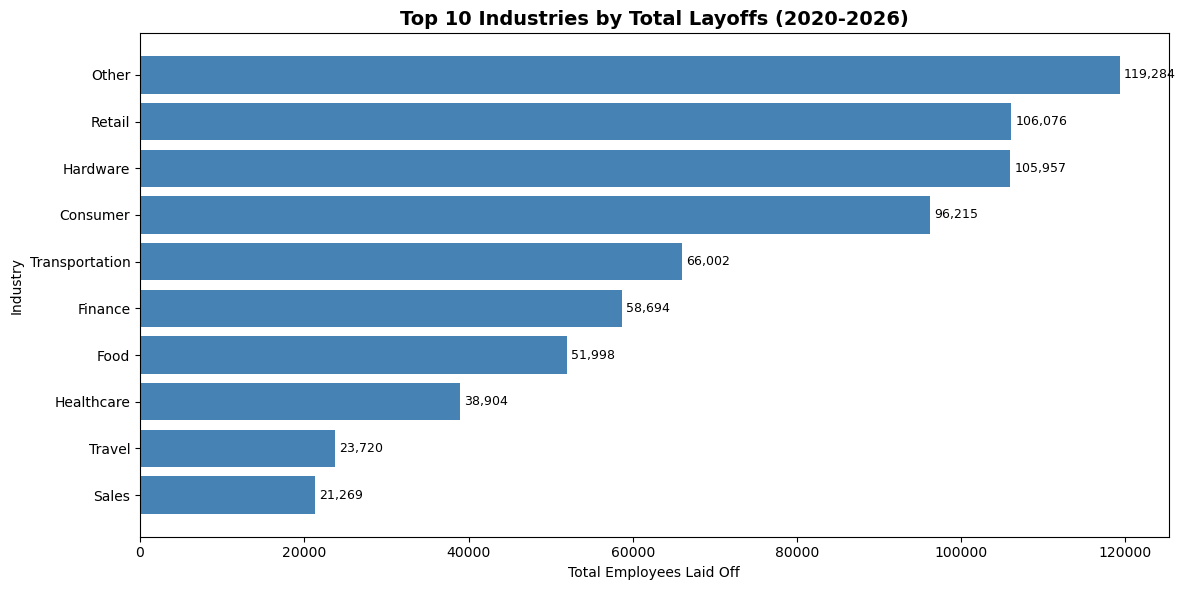

In [66]:
# Chart 2 - Top 10 industries by total layoffs
industry_data = pd.read_sql("""
    SELECT 
        industry,
        SUM(total_laid_off) as total_laid_off
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    AND industry IS NOT NULL
    GROUP BY industry
    ORDER BY total_laid_off DESC
    LIMIT 10
""", conn)

plt.figure(figsize=(12, 6))
bars = plt.barh(industry_data['industry'][::-1], 
                industry_data['total_laid_off'][::-1], 
                color='steelblue')
plt.title('Top 10 Industries by Total Layoffs (2020-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Total Employees Laid Off')
plt.ylabel('Industry')

# Add value labels
for bar, val in zip(bars, industry_data['total_laid_off'][::-1]):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_layoffs_by_industry.png', dpi=150)
plt.show()

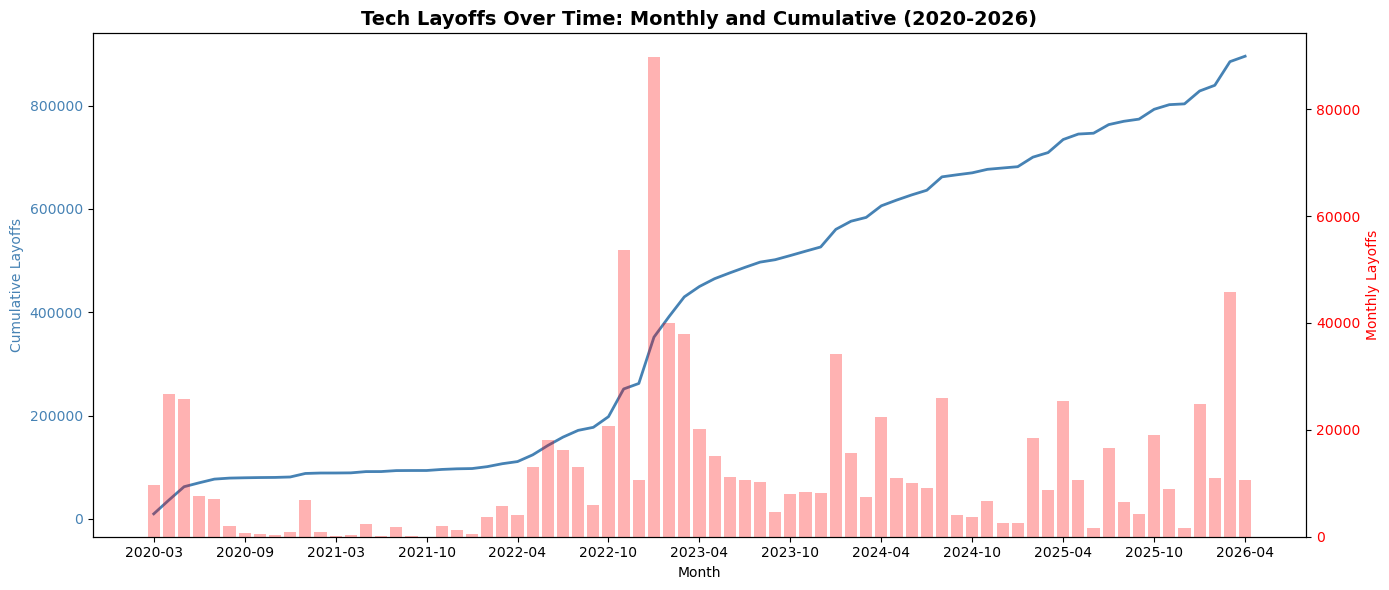

In [68]:
# Chart 3 - Rolling total of layoffs over time
rolling_data = pd.read_sql("""
    WITH monthly AS (
        SELECT 
            strftime('%Y-%m', date) as month,
            SUM(total_laid_off) as monthly_total
        FROM layoffs
        WHERE total_laid_off IS NOT NULL
        AND date IS NOT NULL
        GROUP BY month
    )
    SELECT 
        month,
        monthly_total,
        SUM(monthly_total) OVER (ORDER BY month) as rolling_total
    FROM monthly
    ORDER BY month
""", conn)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Rolling total line
ax1.plot(rolling_data['month'], rolling_data['rolling_total'], 
         color='steelblue', linewidth=2, label='Cumulative Total')
ax1.set_xlabel('Month')
ax1.set_ylabel('Cumulative Layoffs', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Monthly bars on secondary axis
ax2 = ax1.twinx()
ax2.bar(rolling_data['month'], rolling_data['monthly_total'], 
        alpha=0.3, color='red', label='Monthly Total')
ax2.set_ylabel('Monthly Layoffs', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Tech Layoffs Over Time: Monthly and Cumulative (2020-2026)', 
          fontsize=14, fontweight='bold')

# Only show every 6th x label to avoid crowding
tick_positions = range(0, len(rolling_data), 6)
plt.xticks([rolling_data['month'].iloc[i] for i in tick_positions], rotation=45)

plt.tight_layout()
plt.savefig('chart3_rolling_layoffs.png', dpi=150)
plt.show()

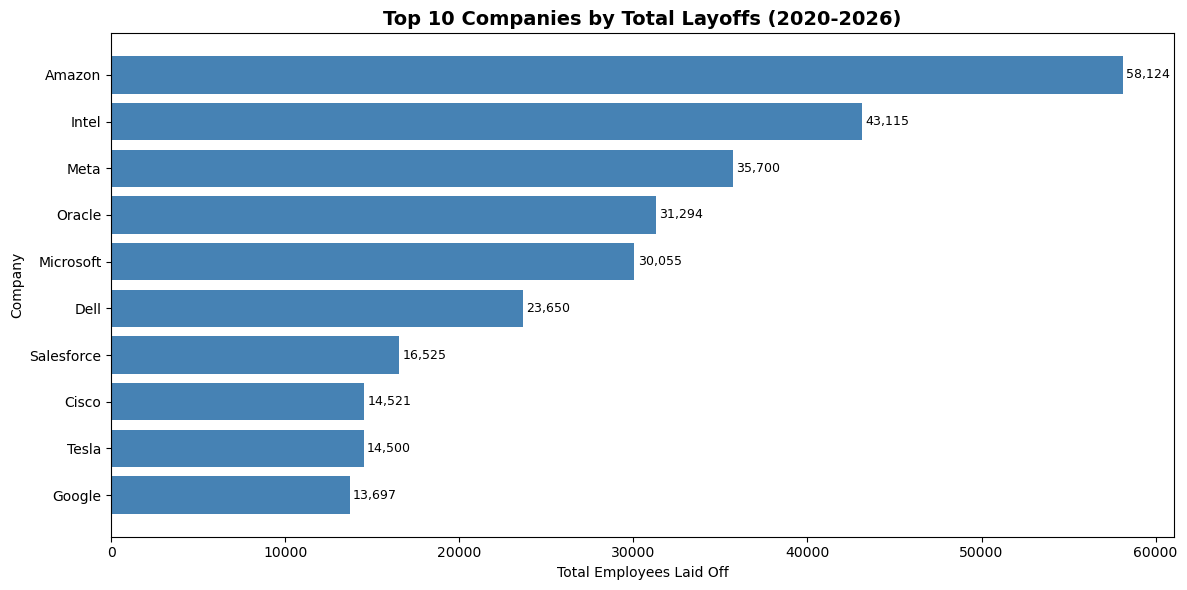

In [70]:
# Chart 4 - Top 10 companies by total layoffs
company_data = pd.read_sql("""
    SELECT 
        company,
        SUM(total_laid_off) as total_laid_off
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    GROUP BY company
    ORDER BY total_laid_off DESC
    LIMIT 10
""", conn)

plt.figure(figsize=(12, 6))
bars = plt.barh(company_data['company'][::-1],
                company_data['total_laid_off'][::-1],
                color='steelblue')
plt.title('Top 10 Companies by Total Layoffs (2020-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Total Employees Laid Off')
plt.ylabel('Company')

for bar, val in zip(bars, company_data['total_laid_off'][::-1]):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_top_companies.png', dpi=150)
plt.show()